# Keyword Analysis Results for PLANTUML

## Results Dataset

In [1]:
 
import sys
sys.path.append('../')                            
from core.results_analysis import ResultsDataset     
from core.results_analysis import ResultsGraph
df = ResultsDataset().load_dataset_for_language("plantuml")
df.head()
        

,code,"""",#,(,),*,*/,+,",",-,...,note,null,o,one,static,{,|>,},ds,kw_extractor
0,@startuml\n\nclass Organizer {\n String fir...,0,0,0,0,0,0,0,0,10,...,0,0,23,1,0,6,0,6,gpt-4o-mini,Regex
1,@startuml\n\nclass HeadCoach {\n String nam...,0,0,0,0,0,0,0,0,14,...,1,0,40,0,0,9,7,9,gpt-4o-mini,Regex
2,@startuml\n\nclass Doctor {\n String practi...,0,0,0,0,0,0,0,0,10,...,0,0,33,3,0,6,0,6,gpt-4o-mini,Regex
3,@startuml\n\nclass City {\n String name\n ...,0,0,0,0,0,0,0,0,8,...,0,0,13,0,0,5,0,5,gpt-4o-mini,Regex
4,@startuml\n\nclass Person {\n String person...,0,0,0,0,0,0,0,0,8,...,0,0,27,1,0,7,0,7,gpt-4o-mini,Regex


### List of **RAW** Keywords (including metadata)

In [2]:
 
df.columns
        

Index(['code', '"', '#', '(', ')', '*', '*/', '+', ',', '-', '.', '..', '/',
       '/*', ':', '<', '<<', '<>', '<|', '=', '>', '>>', '@enduml',
       '@startuml', 'List', '[', '\'', '\n', '\r', ']', '^', 'abstract',
       'class', 'enum', 'extends', 'interface', 'many', 'note', 'null', 'o',
       'one', 'static', '{', '|>', '}', 'ds', 'kw_extractor'],
      dtype='object')

## Keyword groups and filters

In [3]:
# EXCLUDE keywords
excluded_keywords = ['/*', '*/', '\\u2211', '\\u222B', '\\\\', "\\'", '"', ',', '.', '_', 'u']
   
# GROUP keywords
grouped_keywords = {'other_uml_type': ['Sequence', 'Set', 'Bag', 'OrderedSet', 'SortedSet', 'Map', 'SortedMap', 'Function'], 'leftAncestorSymbol': ['<|--', '<|-', '<|---', '<|..', '^--'], 'visibility': ['+', '-', '#', '~'], 'modifier': ['static', 'classifier', 'abstract'], 'rightAncestorSymbol': ['--|>', '-|>', '---|>', '..|>', '--^'], 'associationSymbol': ['-', '--', '---', '-->', '->', '<--', '<-'], 'aggregationSymbol': ['o--', '--o', 'o-->', '<--o'], 'compositionSymbol': ['*--', '*-', '--*', '-*', '*-->', '*->', '<--*', '<-*'], 'dependencySymbol': ['..', '..>', '<..', '...', '...>', '<...'], 'direction': ['>', '<'], 'stereotype': ['<<', '>>']}
df = ResultsDataset().filter_and_group_keywords(df, excluded_keywords, None)
df.head()                    
        

,code,#,(,),*,+,-,..,/,:,...,note,null,o,one,static,{,|>,},ds,kw_extractor
0,@startuml\n\nclass Organizer {\n String fir...,0,0,0,0,0,10,0,0,5,...,0,0,23,1,0,6,0,6,gpt-4o-mini,Regex
1,@startuml\n\nclass HeadCoach {\n String nam...,0,0,0,0,0,14,0,0,7,...,1,0,40,0,0,9,7,9,gpt-4o-mini,Regex
2,@startuml\n\nclass Doctor {\n String practi...,0,0,0,0,0,10,0,0,0,...,0,0,33,3,0,6,0,6,gpt-4o-mini,Regex
3,@startuml\n\nclass City {\n String name\n ...,0,0,0,0,0,8,0,0,4,...,0,0,13,0,0,5,0,5,gpt-4o-mini,Regex
4,@startuml\n\nclass Person {\n String person...,0,0,0,0,0,8,0,0,4,...,0,0,27,1,0,7,0,7,gpt-4o-mini,Regex


### List of **CLEANED** Keywords (including metadata)

In [4]:
 
df.columns
        

Index(['code', '#', '(', ')', '*', '+', '-', '..', '/', ':', '<', '<<', '<>',
       '<|', '=', '>', '>>', '@enduml', '@startuml', 'List', '[', '\n', '\r',
       ']', '^', 'abstract', 'class', 'enum', 'extends', 'interface', 'many',
       'note', 'null', 'o', 'one', 'static', '{', '|>', '}', 'ds',
       'kw_extractor'],
      dtype='object')

## Keyword Coverage per dataset by Extractor

### GoldenUMLmodelset

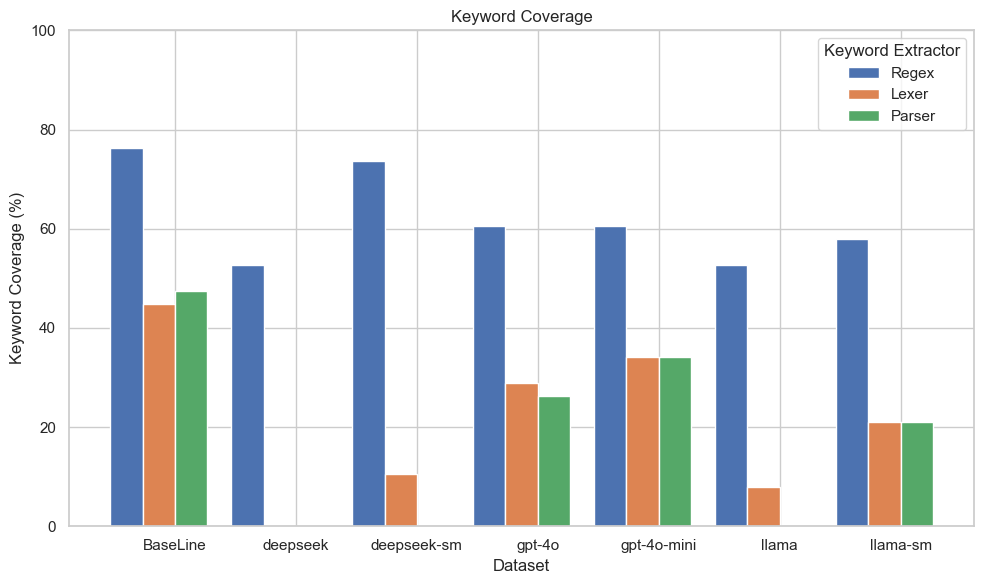

In [5]:
 
ResultsGraph(df).keyword_coverage_per_dataset_by_extractor(['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                

## Uncovered Keywords by Extractor

In [6]:
 
from core.results_analysis import ResultsCoverage

test = ResultsCoverage(df)
print("Uncovered keywords REGEX", test.get_uncovered_keywords( test.compute_coverage(test.filter_kw_extractor_to_regex())) )
print("Uncovered keywords LEXER", test.get_uncovered_keywords( test.compute_coverage(test.filter_kw_extractor_to_lexer()) ))
print("Uncovered keywords PARSER", test.get_uncovered_keywords( test.compute_coverage(test.filter_kw_extractor_to_parser()) ))
        

Uncovered keywords REGEX ['interface', 'many', 'null', '^', '\\r']
Uncovered keywords LEXER ['one', 'static', 'null', 'note', 'many', 'interface', '#', '^', ']', '\\r', '\\n', 'List', '>>', '=', '<>', '<<', ':', '/', '+', '[']
Uncovered keywords PARSER ['one', 'null', 'note', 'many', 'interface', '#', '^', ']', '\\r', '\\n', 'List', '>>', '=', '<>', '<<', ':', '/', '+', '[']


## Keyword groups Frequency by dataset

Considerations:
- Frequencies of keywords are extracted with a Lexer only.
- Frequency are normalized by dataset (the counts between datasets can be comparable now).
- Keywords are grouped to improve understanding.
        

In [7]:
 
df = ResultsDataset().load_dataset_for_language("plantuml")
df = ResultsDataset().filter_and_group_keywords(df, excluded_keywords, grouped_keywords)                            
        

### GoldenUMLmodelset

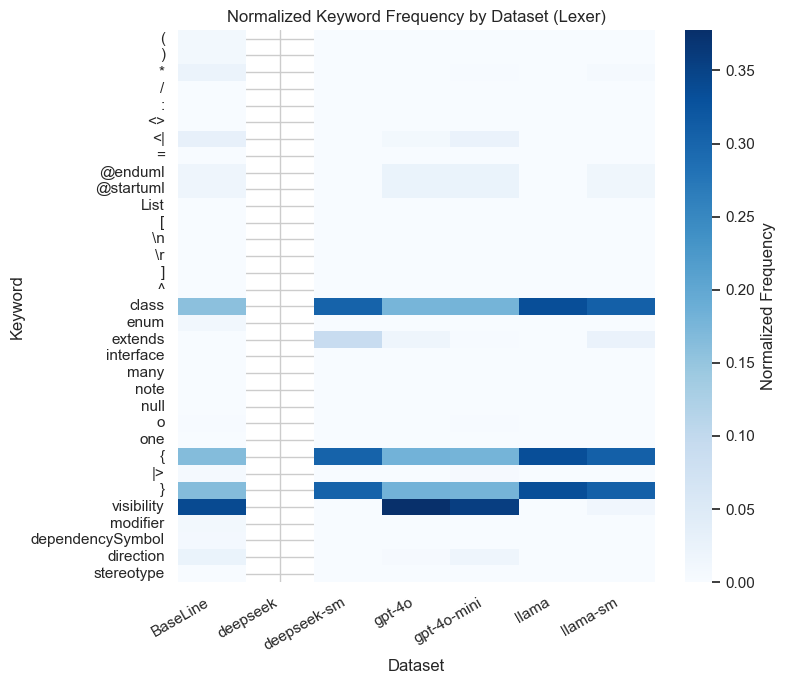

In [8]:
 
ResultsGraph(df).keyword_frequency_by_dataset_heatmap(7, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                

## Detail of individual Keywords Frequency by dataset

Considerations:
- Frequencies of keywords are extracted with a Lexer only.
- Frequency are normalized by dataset (the counts between datasets can be comparable now).
        

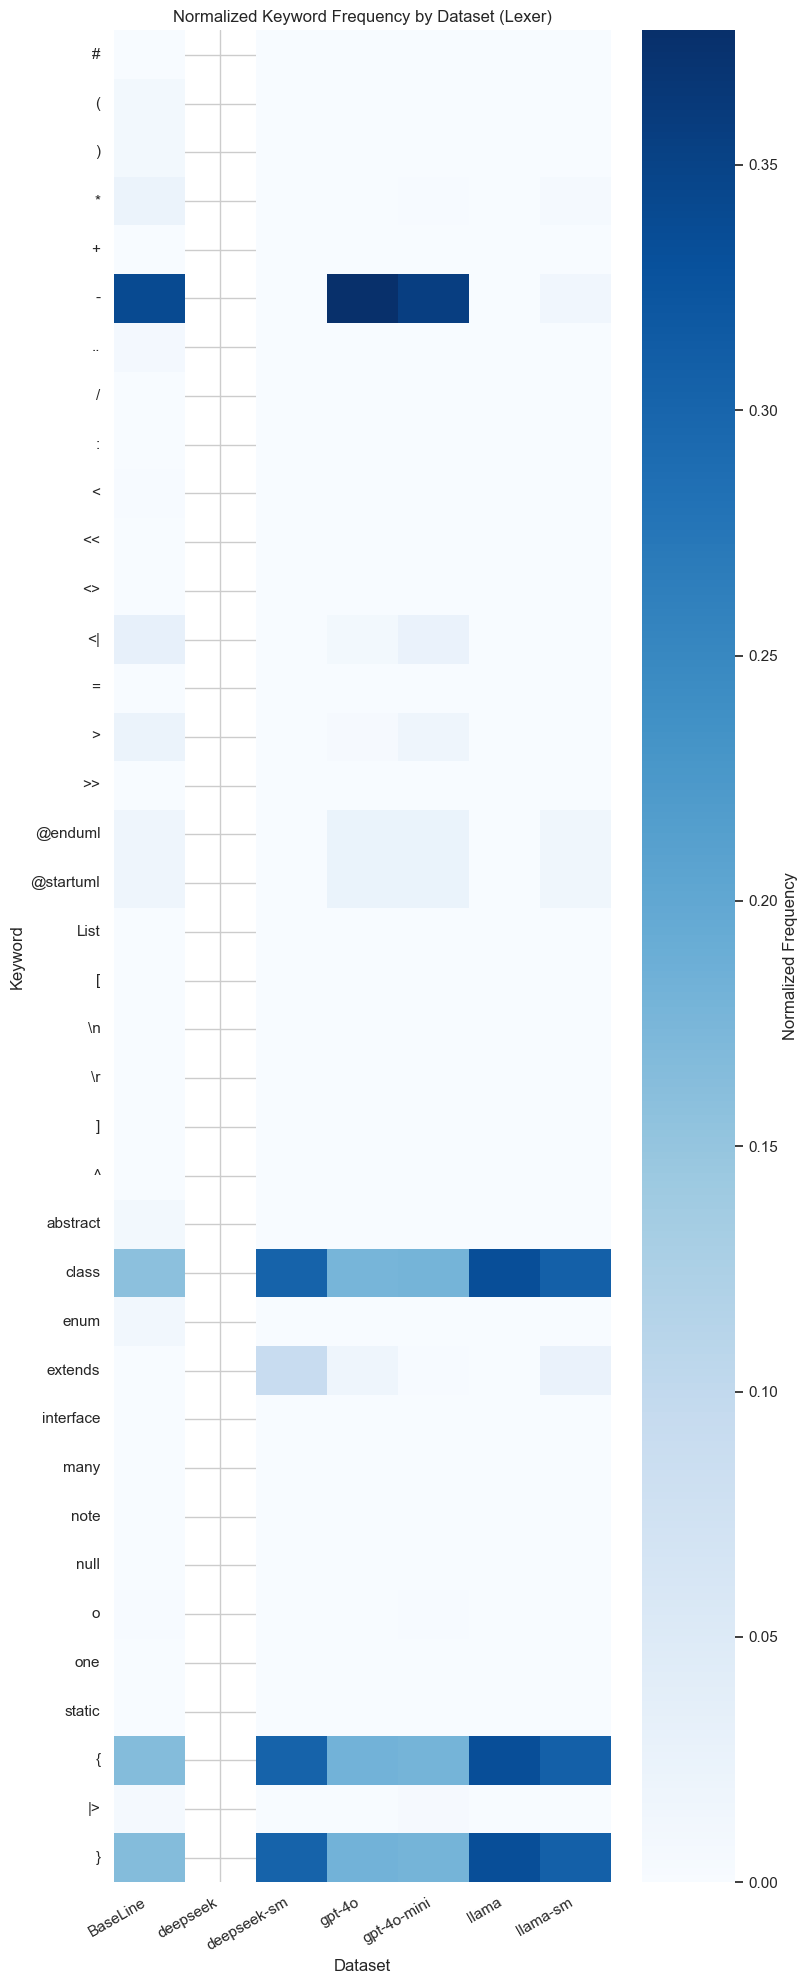

In [9]:
 
df = ResultsDataset().load_dataset_for_language("plantuml")
df = ResultsDataset().filter_and_group_keywords(df, excluded_keywords, None)                            
ResultsGraph(df).keyword_frequency_by_dataset_heatmap()
        

## Keyword variance

Considerations:
- Frequencies of keywords are extracted with a Lexer only.
        

In [10]:
 
df = ResultsDataset().load_dataset_for_language("plantuml")
df = ResultsDataset().filter_and_group_keywords(df, excluded_keywords, grouped_keywords)                            
        

### GoldenUMLmodelset

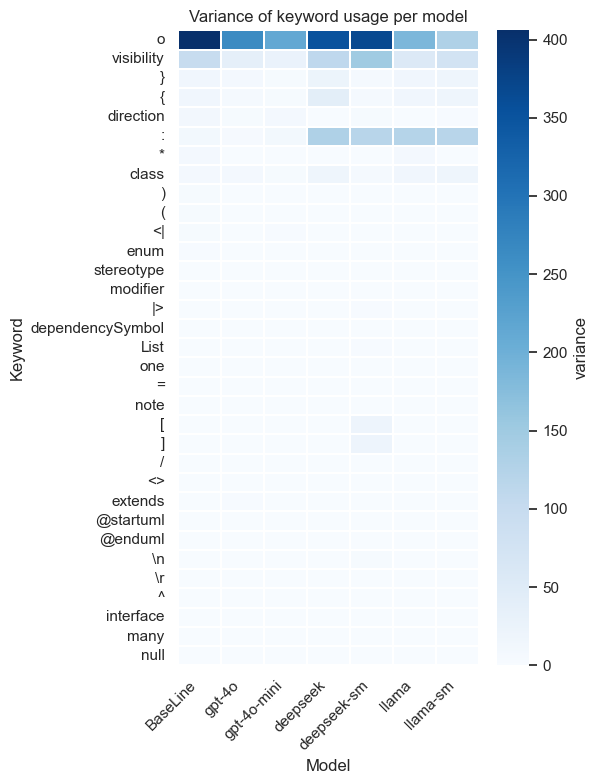

In [11]:
 
ResultsGraph(df).plot_variance_analysis(['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                

# Syntactical Analysis

In [12]:

# If there are no groups, the gruoup is the set of keywords - exclused_keywords
grouped_keywords = ResultsDataset().check_for_group_consistency(df, grouped_keywords, excluded_keywords)

# Load datasets
df = ResultsDataset().load_dataset_for_language("plantuml")
syntactically_correct_kw_ds, total_kw_ds, rule_usage_vectors_ds, rule_correct_vectors_ds, rule_usage_accuracy_ds, rule_errors_ds, parser_lexer_errors, tree_depth_and_size, sequences_ds = ResultsDataset().load_syntactic_analysis_dataset_for_language("plantuml")

# Exclude columns not relevant for analysis, but NO GROUPING
df = ResultsDataset().filter_and_group_keywords(df, excluded_keywords, None)
syntactically_correct_kw_ds = ResultsDataset().filter_and_group_keywords(syntactically_correct_kw_ds, excluded_keywords, None)
total_kw_ds = ResultsDataset().filter_and_group_keywords(total_kw_ds, excluded_keywords, None)


grouped_tables = ResultsCoverage(df).get_grouped_tables(df, syntactically_correct_kw_ds, total_kw_ds, grouped_keywords)

        


## Questions:
- 1. Which language keywords does the LLM recognize and use appropriately? 
- 2. Which language keywords does the LLM fail to recognize or use correctly?
        

### GoldenUMLmodelset

In [13]:

ResultsCoverage(df).get_keyword_coverage_and_correctness_table_v2(df, syntactically_correct_kw_ds, total_kw_ds, rule_usage_vectors_ds, rule_correct_vectors_ds, tree_depth_and_size, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                

,Dataset,KCR,KPV,RCR,RPV,SVR,TDM,TSM
0,BaseLine,0.47,1.00,0.88,1.00,1.00,5.00,351.53
2,gpt-4o-mini,0.34,1.00,0.76,1.00,0.98,5.00,271.29
1,gpt-4o,0.29,0.89,0.82,1.00,0.91,4.93,288.96
6,llama-sm,0.32,0.52,0.59,0.95,0.29,3.53,139.93
3,deepseek,0.24,0.63,0.65,0.93,0.00,4.87,248.38
4,deepseek-sm,0.34,0.52,0.76,0.97,0.00,3.87,145.73
5,llama,0.32,0.77,0.65,0.95,0.00,3.73,177.54


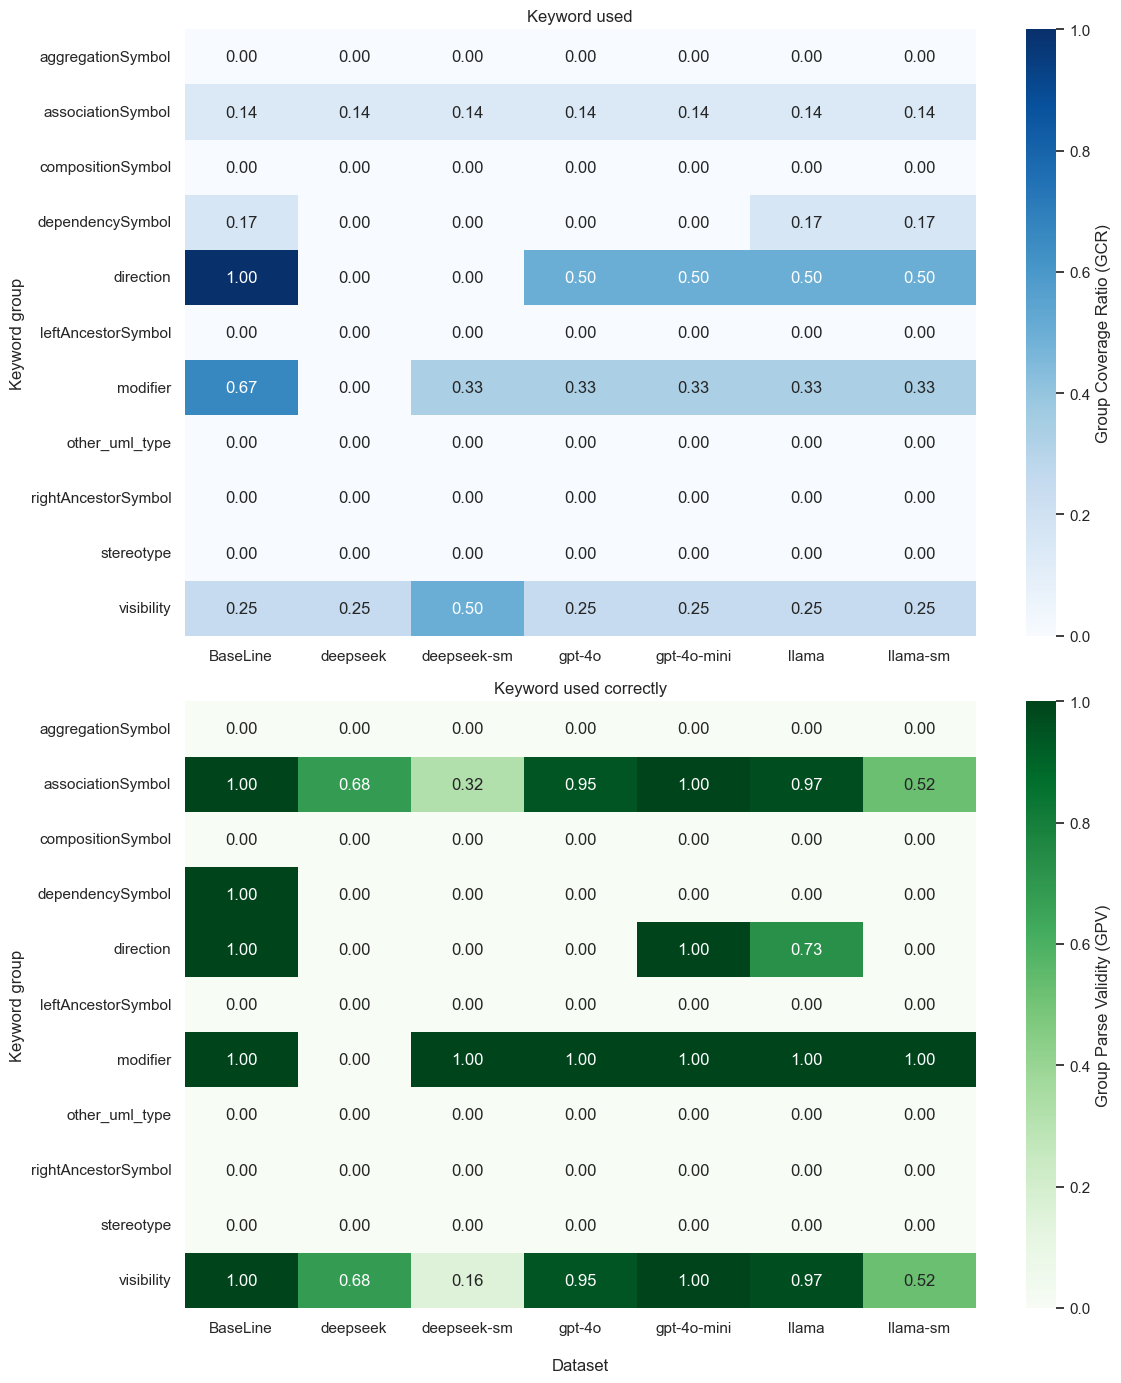

In [14]:
 
ResultsGraph(df).plot_heatmap_keyword_usage(grouped_tables, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                

## Detail Table for each dataset

In [15]:
 
grouped_tables["BaseLine"]
            

,Group,Uses,Correctly
0,other_uml_type,0.000,0.0
1,leftAncestorSymbol,0.000,0.0
2,visibility,0.250,1.0
3,modifier,0.667,1.0
4,rightAncestorSymbol,0.000,0.0
5,associationSymbol,0.143,1.0
6,aggregationSymbol,0.000,0.0
7,compositionSymbol,0.000,0.0
8,dependencySymbol,0.167,1.0
9,direction,1.000,1.0


In [16]:
 
grouped_tables["gpt-4o"]
            

,Group,Uses,Correctly
0,other_uml_type,0.000,0.000
1,leftAncestorSymbol,0.000,0.000
2,visibility,0.250,0.946
3,modifier,0.333,1.000
4,rightAncestorSymbol,0.000,0.000
5,associationSymbol,0.143,0.946
6,aggregationSymbol,0.000,0.000
7,compositionSymbol,0.000,0.000
8,dependencySymbol,0.000,0.000
9,direction,0.500,0.000


In [17]:
 
grouped_tables["gpt-4o-mini"]
            

,Group,Uses,Correctly
0,other_uml_type,0.000,0.0
1,leftAncestorSymbol,0.000,0.0
2,visibility,0.250,1.0
3,modifier,0.333,1.0
4,rightAncestorSymbol,0.000,0.0
5,associationSymbol,0.143,1.0
6,aggregationSymbol,0.000,0.0
7,compositionSymbol,0.000,0.0
8,dependencySymbol,0.000,0.0
9,direction,0.500,1.0


In [18]:
 
grouped_tables["deepseek"]
            

,Group,Uses,Correctly
0,other_uml_type,0.000,0.00
1,leftAncestorSymbol,0.000,0.00
2,visibility,0.250,0.68
3,modifier,0.000,0.00
4,rightAncestorSymbol,0.000,0.00
5,associationSymbol,0.143,0.68
6,aggregationSymbol,0.000,0.00
7,compositionSymbol,0.000,0.00
8,dependencySymbol,0.000,0.00
9,direction,0.000,0.00


In [19]:
 
grouped_tables["llama"]
            

,Group,Uses,Correctly
0,other_uml_type,0.000,0.000
1,leftAncestorSymbol,0.000,0.000
2,visibility,0.250,0.969
3,modifier,0.333,1.000
4,rightAncestorSymbol,0.000,0.000
5,associationSymbol,0.143,0.969
6,aggregationSymbol,0.000,0.000
7,compositionSymbol,0.000,0.000
8,dependencySymbol,0.167,0.000
9,direction,0.500,0.727


In [20]:
 
grouped_tables["deepseek-sm"]
            

,Group,Uses,Correctly
0,other_uml_type,0.000,0.000
1,leftAncestorSymbol,0.000,0.000
2,visibility,0.500,0.160
3,modifier,0.333,1.000
4,rightAncestorSymbol,0.000,0.000
5,associationSymbol,0.143,0.319
6,aggregationSymbol,0.000,0.000
7,compositionSymbol,0.000,0.000
8,dependencySymbol,0.000,0.000
9,direction,0.000,0.000


In [21]:
 
grouped_tables["llama-sm"]
            

,Group,Uses,Correctly
0,other_uml_type,0.000,0.000
1,leftAncestorSymbol,0.000,0.000
2,visibility,0.250,0.524
3,modifier,0.333,1.000
4,rightAncestorSymbol,0.000,0.000
5,associationSymbol,0.143,0.524
6,aggregationSymbol,0.000,0.000
7,compositionSymbol,0.000,0.000
8,dependencySymbol,0.167,0.000
9,direction,0.500,0.000



## Syntactically Correct Rule Usage
        

### GoldenUMLmodelset

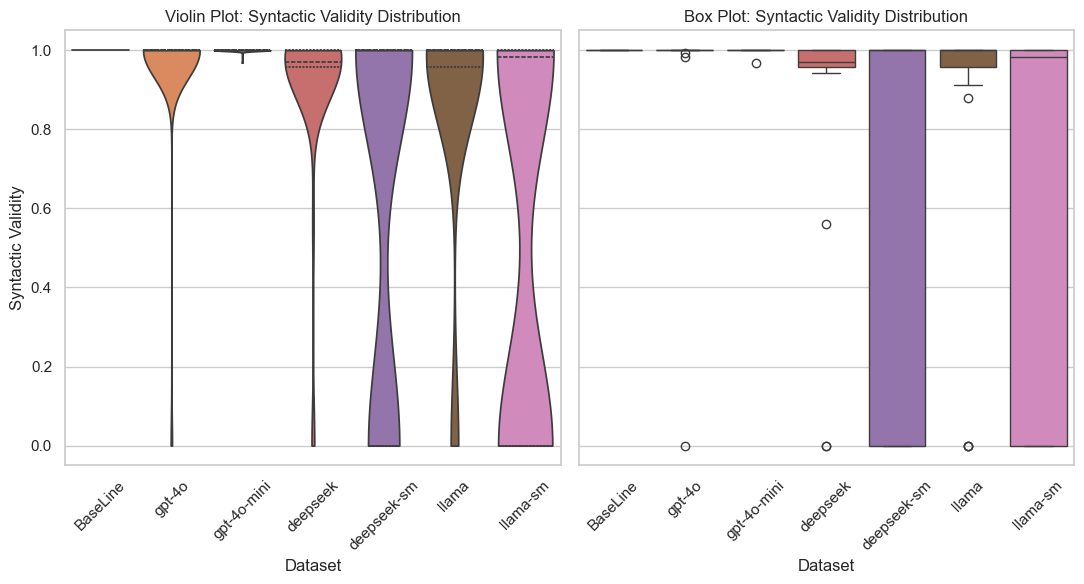

In [22]:
 
ResultsGraph(df).syntactically_correct_rule_usage_distribution(rule_usage_accuracy_ds, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                


## Rule usage ratio by dataset
        

In [23]:

rules_usage_summary = ResultsCoverage(df).get_rule_usage_summary(rule_usage_vectors_ds, rule_correct_vectors_ds)
rule_usage_avg_accuracy = ResultsCoverage(df).get_rule_usage_avg_accuracy(rules_usage_summary)
        

### GoldenUMLmodelset

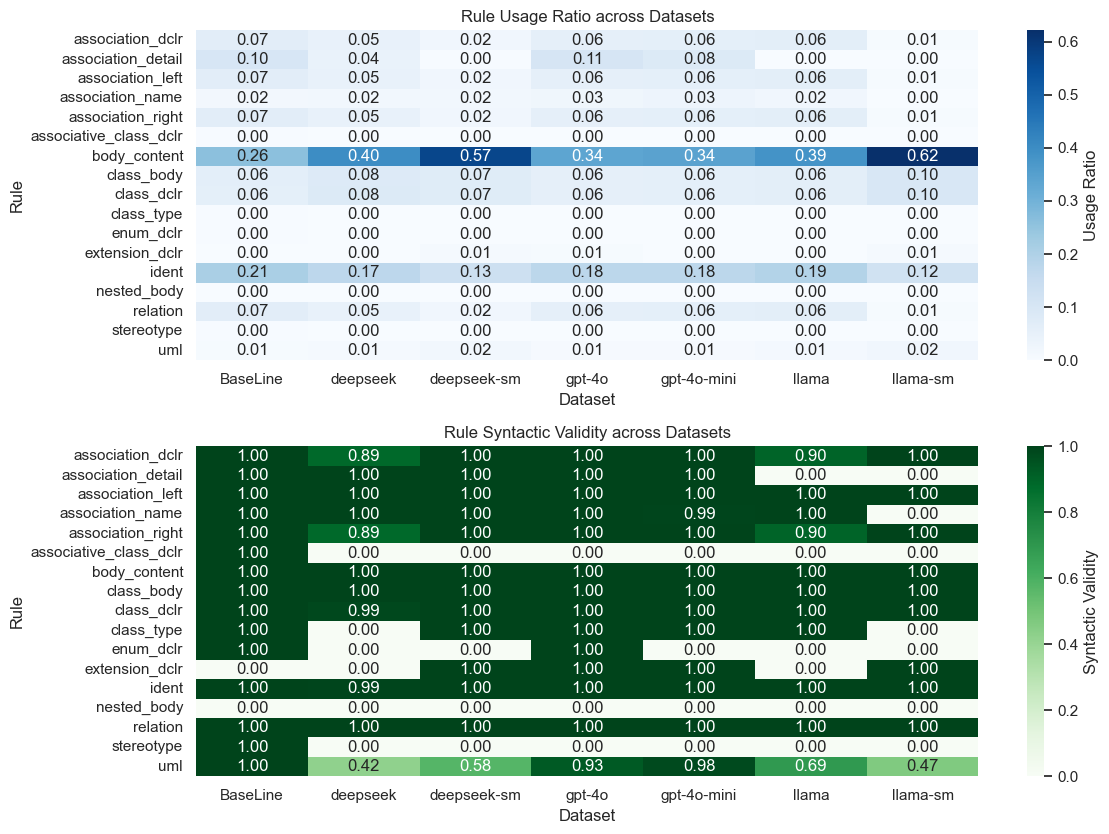

In [24]:
 
ResultsGraph(df).plot_heatmap_rule_usage_summary(rules_usage_summary, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                

## Rule usage variance

### GoldenUMLmodelset

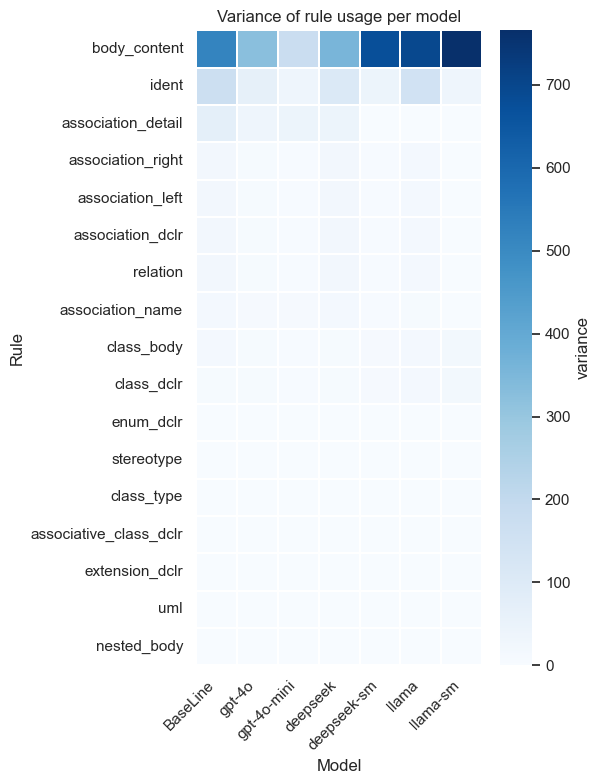

In [25]:
 
ResultsGraph(df).plot_rule_variance_analysis(rule_usage_vectors_ds, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                

## Tree size and depth


                            
- Do LLMs generate simple flat constructs? Are the LLM-generated programs reaching the same complexity region as human-written ones?
- Can LLMs use deeply nested or recursive syntax? How does the "shape" of complexity differ across datasets (LLMs)?
        

### GoldenUMLmodelset

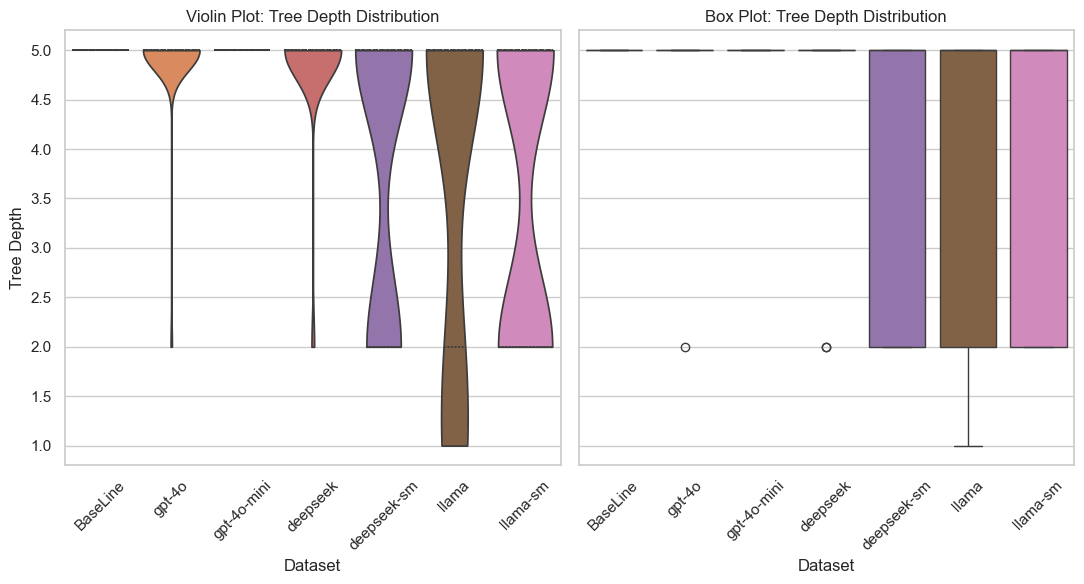

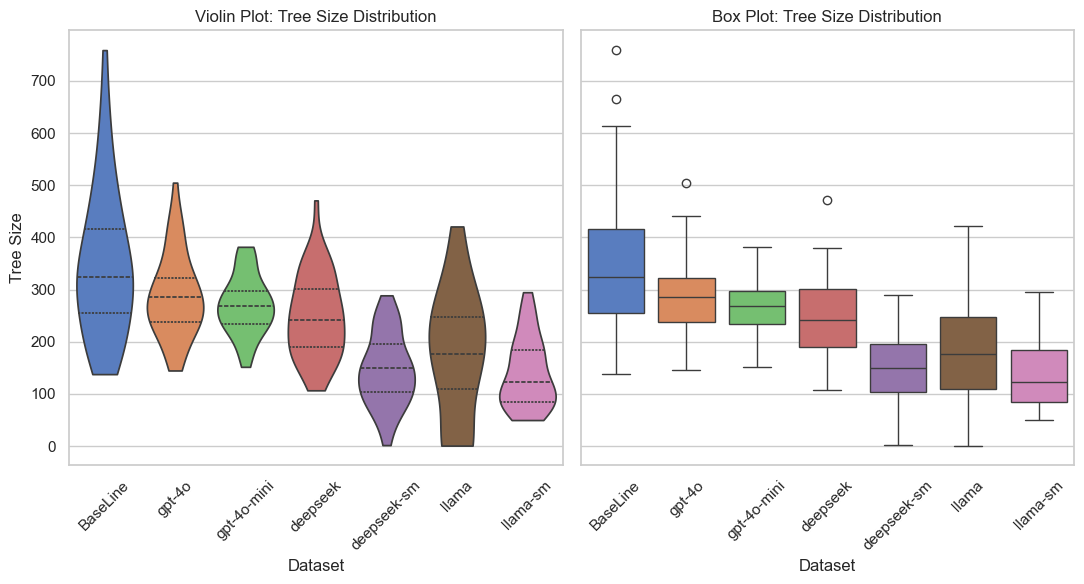


=== Summary Statistics ===

             depth_mean  depth_95   size_mean  size_95  count
ds                                                           
BaseLine       5.000000       5.0  351.533333    610.6     45
gpt-4o         4.933333       5.0  288.955556    438.4     45
gpt-4o-mini    5.000000       5.0  271.288889    372.6     45
deepseek       4.866667       5.0  248.377778    371.4     45
deepseek-sm    3.866667       5.0  145.733333    258.0     45
llama          3.730769       5.0  177.538462    371.0     26
llama-sm       3.533333       5.0  139.933333    252.4     45


In [26]:
 
ResultsGraph(df).plot_tree_depth_and_size_analisis(tree_depth_and_size, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                


# Errors
        

In [27]:

parser_lexer_errors = ResultsCoverage(df).get_errors_with_generic_antlr_types(parser_lexer_errors)
        


## Error detail by rule and dataset
        

In [28]:

rule_errors_ds = ResultsCoverage(df).get_rule_errors_with_generic_antlr_types(rule_errors_ds)
        

### GoldenUMLmodelset


#### What rules do we need to address first?
                

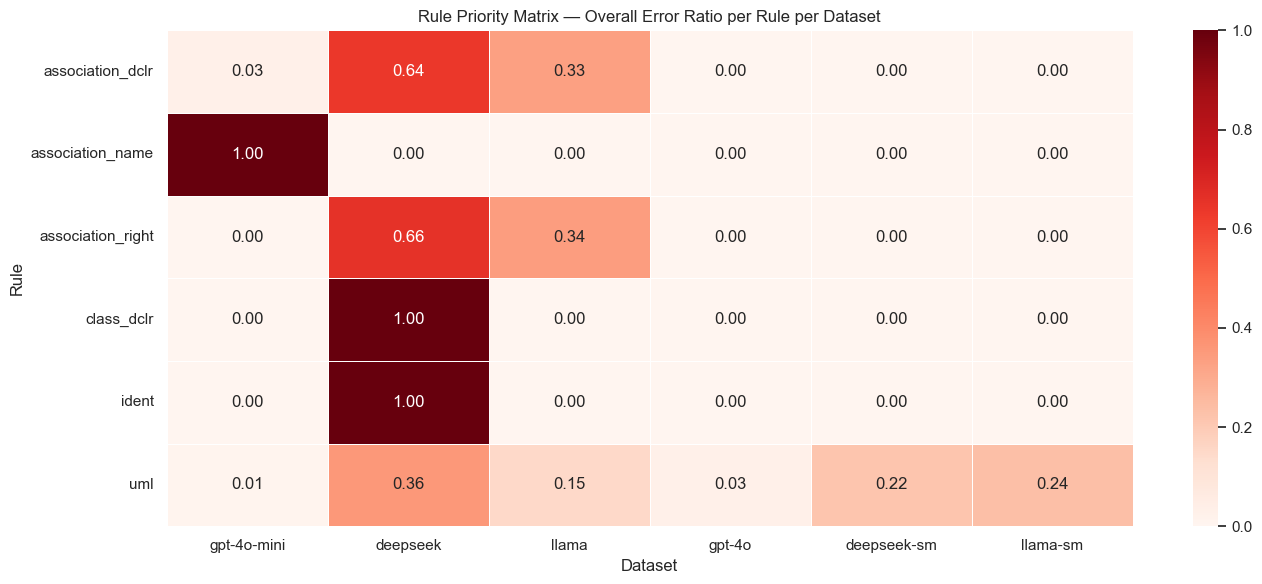

In [29]:

ResultsGraph(df).plot_rule_priority_matrix(rule_errors_ds, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                


#### What type of error are found in the dataset of the target model I need to improve detailed by rule?        
                

In [30]:
 
ResultsGraph(df).plot_rule_error_types_for_ds("BaseLine", rule_errors_ds)
                	

⚠️ **Warning:** No rule errors were found!

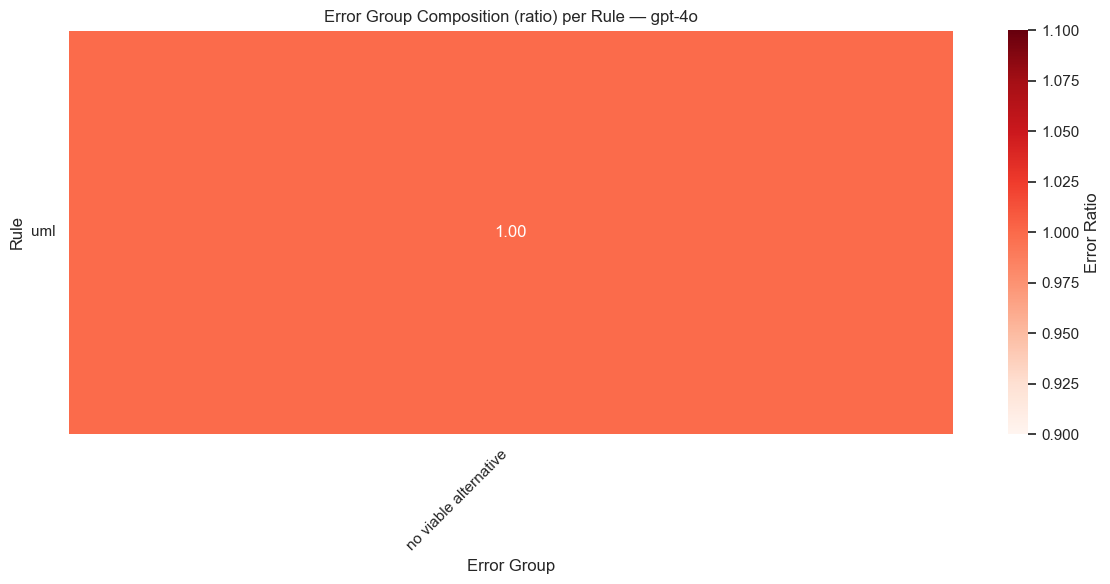

In [31]:
 
ResultsGraph(df).plot_rule_error_types_for_ds("gpt-4o", rule_errors_ds)
                	

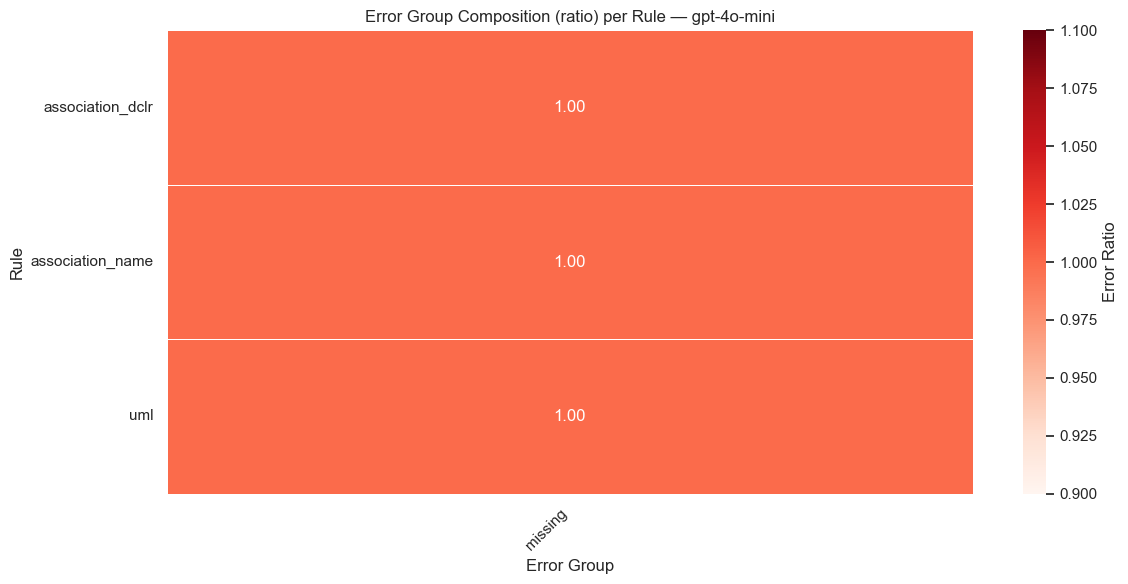

In [32]:
 
ResultsGraph(df).plot_rule_error_types_for_ds("gpt-4o-mini", rule_errors_ds)
                	

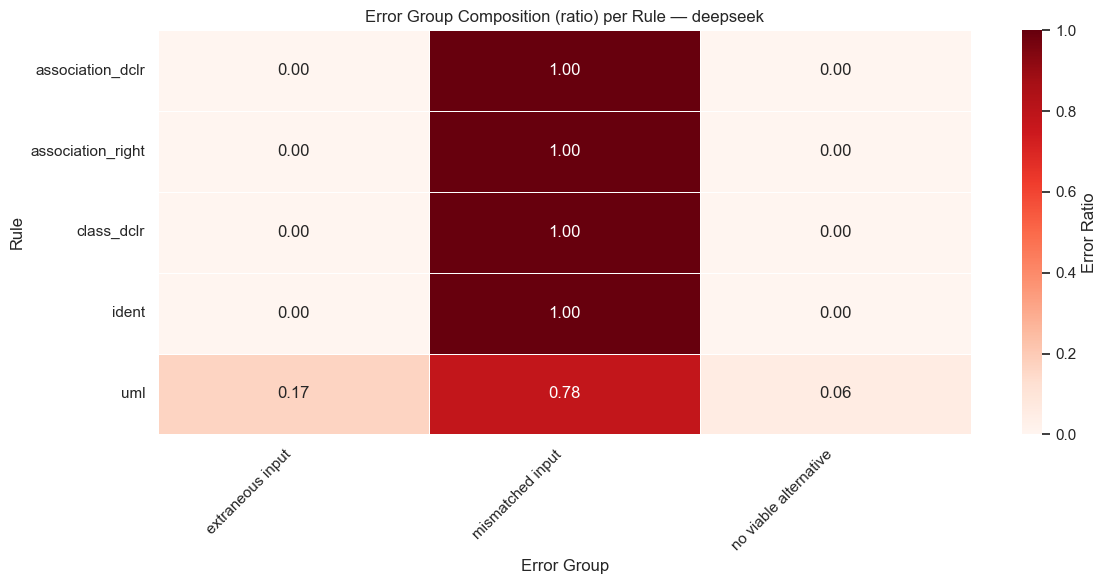

In [33]:
 
ResultsGraph(df).plot_rule_error_types_for_ds("deepseek", rule_errors_ds)
                	

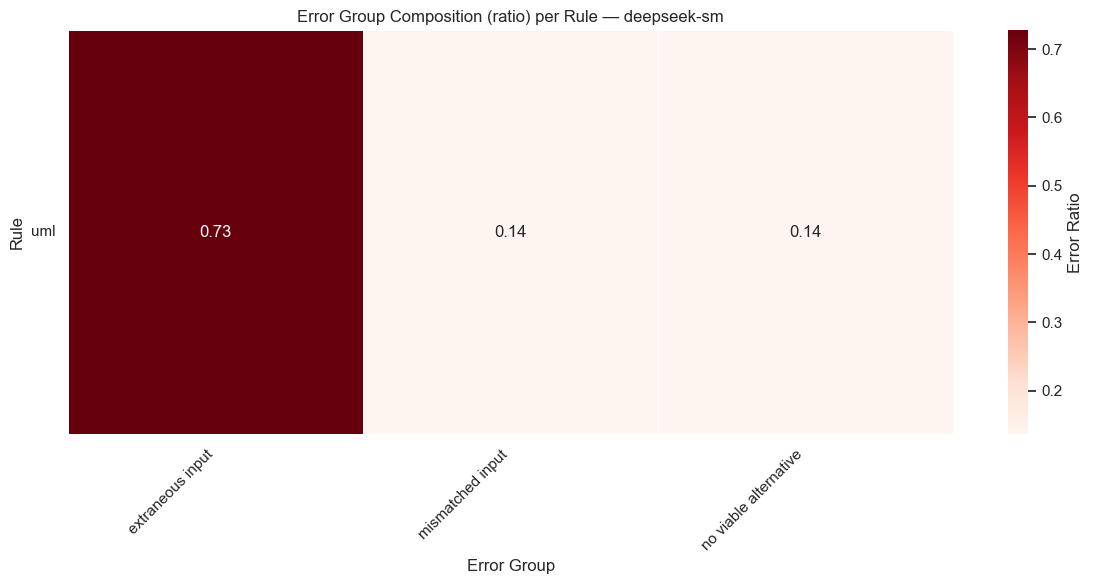

In [34]:
 
ResultsGraph(df).plot_rule_error_types_for_ds("deepseek-sm", rule_errors_ds)
                	

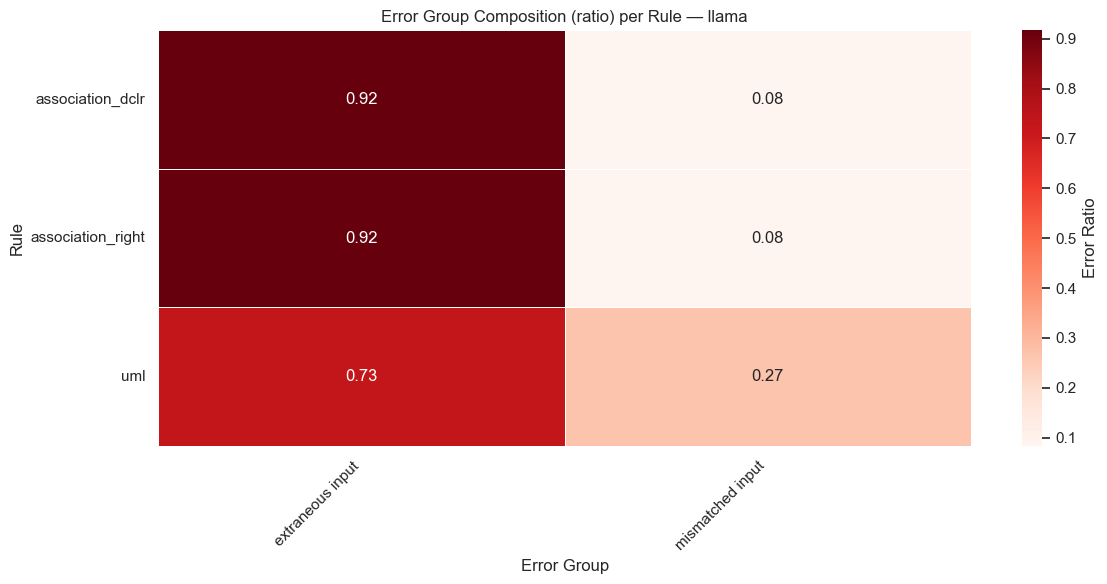

In [35]:
 
ResultsGraph(df).plot_rule_error_types_for_ds("llama", rule_errors_ds)
                	

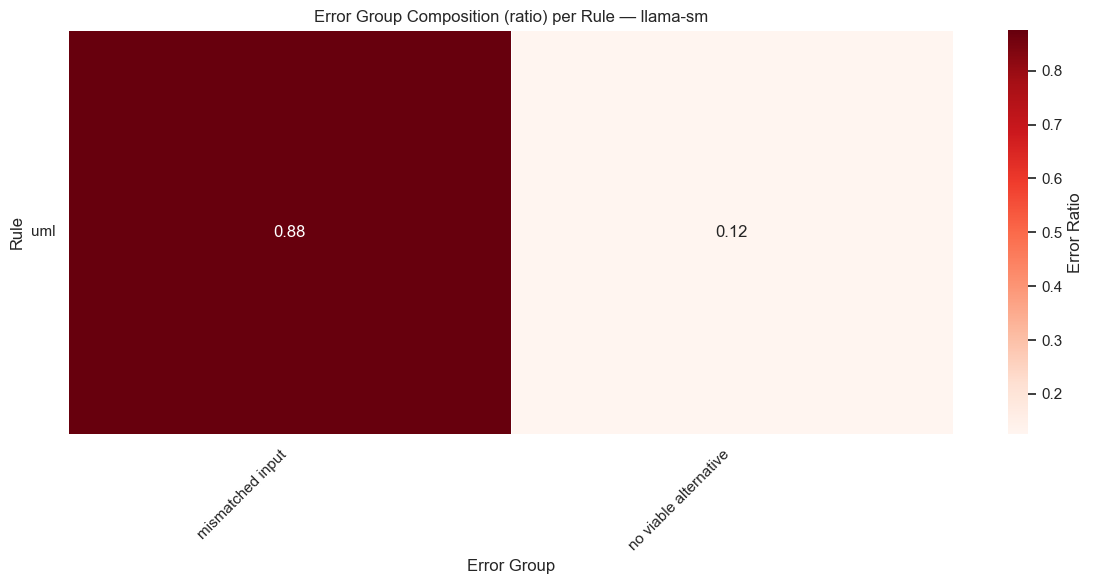

In [36]:
 
ResultsGraph(df).plot_rule_error_types_for_ds("llama-sm", rule_errors_ds)
                	


## Lexer and Parser errors detail
        

### GoldenUMLmodelset

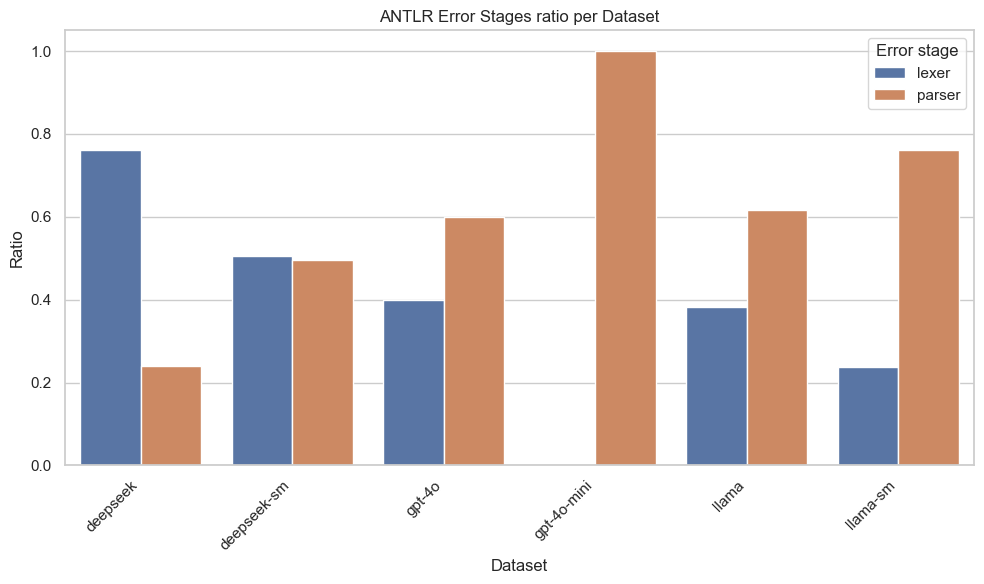

In [37]:

ResultsGraph(df).plot_error_stage_per_dataset(parser_lexer_errors, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                


## Error detail per dataset
        

### GoldenUMLmodelset

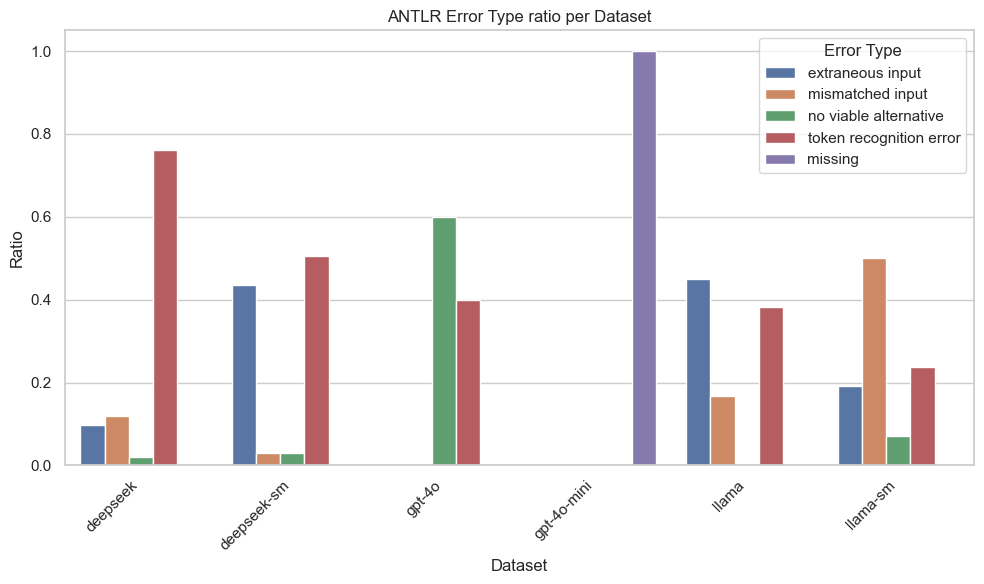

In [38]:

ResultsGraph(df).plot_error_type_ratio_per_dataset(parser_lexer_errors, ['BaseLine', 'gpt-4o', 'gpt-4o-mini', 'deepseek', 'deepseek-sm', 'llama', 'llama-sm'])
                